# TD Learning: SARSA (On-Policy)

**Series:** RL from scratch · Model-Free Learning · Part 2  

In this notebook I move from Monte Carlo to TD learning. Instead of waiting till the end of every game to get the full return, TD updates the Q values after **every single step**, using the reward it just got plus its own current estimate of what comes next. SARSA is the on-policy version of this: it learns the values of the exact ε-greedy policy it's playing with.

**Contents**
1. The problem with Monte Carlo
2. TD learning: the idea
3. TD targets: MC vs SARSA vs Q-learning
4. Bootstrapping
5. SARSA: on-policy TD control
6. Where's the policy improvement step?
7. Termination vs truncation
8. Setup
9. ε-greedy action selection
10. The SARSA update
11. The SARSA loop
12. Results on FrozenLake
13. Experiment: decaying ε
14. SARSA on CliffWalking: playing it safe
15. Summary: Monte Carlo vs TD

## 1. The problem with Monte Carlo

Monte Carlo updates toward the full return, which is only known once the game is over:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha\,\big[G_t - Q(s, a)\big], \qquad G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots
$$

$G_t$ is the actual sum of rewards **till the end of the game**, so I have to finish every game before updating anything.

That's a problem because:
- **Games can be really long.** The agent keeps playing with the same (possibly bad) Q values the whole time, and doesn't learn anything until the end.
- **Some tasks never end.** A robot that keeps running, or a trading agent, has no "end of the game" to wait for.
- **High variance.** $G_t$ adds up every random action, slip and reward till the end, so it can swing a lot from game to game.

It would be much nicer to learn **during** the game, after every step.

## 2. TD learning: the idea

Instead of waiting for $G_t$, use the reward we just got plus our **current estimate** of what comes next. For state values (TD(0) prediction):

$$
V(S_t) \leftarrow V(S_t) + \alpha\,\big[\underbrace{R_{t+1} + \gamma\, V(S_{t+1})}_{\text{TD target}} - V(S_t)\big]
$$

The bracket is the **TD error**:

$$
\delta_t = R_{t+1} + \gamma\, V(S_{t+1}) - V(S_t)
$$

The key is that the return is recursive:

$$
G_t = R_{t+1} + \gamma\, G_{t+1}
$$

So the return from now = the reward I get next + γ × the return from the next step onwards. I don't know $G_{t+1}$ until the game ends, but my current estimate of that future return is already sitting in my value table as $V(S_{t+1})$. So I just plug that in:

$$
G_t \approx R_{t+1} + \gamma\, V(S_{t+1})
$$

Basically we replace the actual discounted sum of rewards till the end of the game with: the reward from the current step + γ × our current estimate of the future return from the next state.

**Why it's called "temporal difference":** $V(S_t)$ is my guess **before** taking the step. $R_{t+1} + \gamma V(S_{t+1})$ is a **better guess one step later**, since it includes one real reward. The difference between the two guesses across time is the TD error, and each update moves $V(S_t)$ a little towards the newer guess.

## 3. TD targets: MC vs SARSA vs Q-learning

Same update shape every time, only the target changes:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha\,\big[\text{Target} - Q(s, a)\big]
$$

| Method | Target |
| --- | --- |
| Monte Carlo | $G_t$ (actual return to the end of the game) |
| SARSA | $r + \gamma\, Q(s', a')$, with $a'$ the action actually picked next |
| Q-learning | $r + \gamma \max_{a'} Q(s', a')$ |

It's the same "old estimate + step size × (target − old estimate)" shape from the online Monte Carlo derivation. The only thing that changes between methods is **what I use as the target**:
- **Monte Carlo** uses only real rewards, all the way to the end.
- **SARSA and Q-learning** use one real reward, then lean on their own estimate. They only differ in **which** next action's Q they use: the one I'll actually take (SARSA) or the best one (Q-learning).

## 4. Bootstrapping

**Bootstrapping** = updating an estimate using another estimate.

$$
\text{DP:}\;\; v(s) \leftarrow \mathbb{E}\big[R_{t+1} + \gamma\, v(S_{t+1})\big] \qquad
\text{MC:}\;\; V(s) \leftarrow V(s) + \alpha\,[G_t - V(s)] \qquad
\text{TD:}\;\; V(s) \leftarrow V(s) + \alpha\,[R_{t+1} + \gamma V(S_{t+1}) - V(s)]
$$

|  | Samples experience? | Bootstraps? |
| --- | --- | --- |
| DP (policy / value iteration) | No, uses the model to average over every outcome | Yes, uses $v(s')$ |
| Monte Carlo | Yes, plays games | No, uses real rewards till the end |
| TD | Yes, plays games | Yes, uses $V(s')$ or $Q(s', a')$ |

So **TD = sampling like Monte Carlo + bootstrapping like DP.** It learns from experience without the model, but doesn't wait for the end of the game.

This creates a **bias-variance trade-off**:
- **Monte Carlo: low bias, high variance.** $G_t$ is the actual return, so on average it's exactly the true value. But it adds up every random step till the end, so it swings a lot.
- **TD: more bias, low variance.** The target has only one step of randomness, so it's much more stable. But it leans on my current guess $Q(s', a')$, which can be wrong (especially early on), and that error leaks into the update. The bias shrinks as the estimates get better.

## 5. SARSA: on-policy TD control

The name comes from the five things each update uses: $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$.

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha\,\big[R_{t+1} + \gamma\, Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)\big]
$$

**On-policy:** $A_{t+1}$ is chosen by the same ε-greedy policy we're learning about, so SARSA learns the value of the policy it actually follows (exploration included).

To make an update I need: the state I was in, the action I took, the reward I got, the state I landed in, **and** the action I'm going to take next. That last one is why I pick the next action **before** updating.

**What on-policy means here:** the next action $A_{t+1}$ comes from the same ε-greedy policy I'm playing with, including its random exploratory moves. So the Q values SARSA learns are the values of **actually playing ε-greedy**, i.e. they already account for the fact that I'll sometimes take a random action. That's what makes SARSA a bit more careful, which shows up nicely on CliffWalking in section 14.

## 6. Where's the policy improvement step?

In the Monte Carlo notebook there was an explicit loop: freeze the policy, play thousands of games to estimate its Q, then `policy = argmax Q`, and repeat. SARSA doesn't have that separate step, but it hasn't disappeared, it's just **hidden and happening all the time**.

SARSA has **no separate policy array**. Every time the agent needs an action, it looks at the **current** Q and picks ε-greedily. So the policy is always "ε-greedy with respect to whatever Q is right now". The moment Q changes after an update, the policy changes too, automatically.

So both halves of policy iteration are still there, just squeezed together:
- **Evaluation:** each update nudges $Q(s, a)$ towards the value of the policy being followed.
- **Improvement:** the next action is picked ε-greedily from the **updated** Q.

With TD, Q changes after **every step**, so freezing the policy for thousands of games would just throw that away. This is called **generalised policy iteration**: evaluation and improvement interleaved at any granularity. Monte Carlo in the previous notebook sat at one end (full evaluation, then improve), SARSA sits at the other (one update, then improve). Similar to how value iteration folds the improvement step into every sweep.

**Does it still reach the optimal policy?** Yes, as long as every state-action pair keeps getting visited and ε slowly decays towards 0, so that the policy ends up greedy. With a fixed ε, SARSA learns the best **ε-greedy** policy, which is slightly more cautious than the truly optimal one (more on this in section 13).

## 7. Termination vs truncation

`env.step` returns both `terminated` and `truncated`:

- **terminated** (hole or goal): there is no future, so the target is just $r$, i.e. $Q(s', \cdot) = 0$
- **truncated** (step limit): the game was cut off, the future still exists, so keep bootstrapping

$$
\text{Target} = r + \gamma\,(1 - \text{terminated})\; Q(s', a')
$$

The episode loop ends on either one: `done = terminated or truncated`.

These two look similar but mean different things for the target:
- **Terminated:** the game is really over (fell in a hole or reached the goal). There's nothing after this state, so there's nothing to bootstrap from: the target is just the reward.
- **Truncated:** the game was **cut off** by the step limit (FrozenLake stops at 100 steps). The agent didn't actually reach an end, it just ran out of time, so the future still exists and I should keep bootstrapping.

If I treated truncation like termination, I'd be telling the agent "this state is worth 0" just because the clock ran out, which teaches it something wrong.

## 8. Setup

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

np.random.seed(0)

### Helpers (not the focus)

`show_policy` draws a policy as arrows on the lake, `plot_curve` is a quick line plot (with optional smoothing), `show_cliff_path` draws the greedy path on CliffWalking.

In [2]:
ARROWS = ["←", "↓", "→", "↑"]
ACTION_NAMES = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}

def print_board(env, state):
    """Text view of the lake; A = agent, S = start, F = frozen, H = hole, G = goal."""
    desc = env.unwrapped.desc.astype(str).copy()
    r, c = divmod(int(state), desc.shape[1])
    desc[r, c] = "A"
    print("\n".join(" ".join(row) for row in desc), "\n")

def show_policy(policy, values=None, env=None, title="Policy"):
    """Grid with policy arrows. values = V (one per state) or Q (states x actions, max is shown)."""
    desc = env.unwrapped.desc.astype(str)
    n_rows, n_cols = desc.shape
    policy = np.asarray(policy).astype(int)
    if values is None:
        grid = np.zeros((n_rows, n_cols))
    else:
        values = np.asarray(values)
        grid = (values.max(axis=1) if values.ndim == 2 else values).reshape(n_rows, n_cols)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid, cmap="viridis", vmin=min(0, grid.min()), vmax=max(grid.max(), 1e-8))
    for s in range(n_rows * n_cols):
        r, c = divmod(s, n_cols)
        cell = desc[r, c]
        if cell == "H":
            ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1, color="black"))
            ax.text(c, r, "H", ha="center", va="center", color="red", fontsize=14)
        elif cell == "G":
            ax.text(c, r, "G", ha="center", va="center", color="gold", fontsize=16, weight="bold")
        else:
            ax.text(c, r - .05, ARROWS[policy[s]], ha="center", va="center", color="white", fontsize=18)
            if values is not None:
                ax.text(c, r + .32, f"{grid[r, c]:.2f}", ha="center", va="center", color="white", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    plt.show()

def plot_curve(y, title="", xlabel="", ylabel="", smooth=None, logy=False):
    """Line plot; smooth = moving-average window (optional); logy = log scale on y."""
    y = np.asarray(y, dtype=float)
    plt.figure(figsize=(6, 3))
    if smooth:
        plt.plot(y, alpha=.25)
        y = np.convolve(y, np.ones(smooth) / smooth, mode="valid")
    plt.plot(y)
    if logy: plt.yscale("log")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.grid(alpha=.3); plt.show()


def show_cliff_path(Q, title="Greedy path"):
    """CliffWalking 4x12: draw the cliff and the greedy path from start to goal."""
    n_rows, n_cols = 4, 12
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.set_xlim(-.5, n_cols - .5); ax.set_ylim(n_rows - .5, -.5)
    for c in range(1, 11):
        ax.add_patch(plt.Rectangle((c - .5, 2.5), 1, 1, color="black"))
    ax.text(0, 3, "S", ha="center", va="center", fontsize=14, weight="bold")
    ax.text(11, 3, "G", ha="center", va="center", fontsize=14, weight="bold", color="green")
    ax.text(5.5, 3, "cliff (-100)", ha="center", va="center", color="red", fontsize=11)
    moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}   # up, right, down, left as (dr, dc)
    s, path = 36, [36]
    for _ in range(60):
        r, c = divmod(s, n_cols); dr, dc = moves[int(np.argmax(Q[s]))]
        r, c = min(max(r + dr, 0), n_rows - 1), min(max(c + dc, 0), n_cols - 1)
        s = 36 if (r == 3 and 1 <= c <= 10) else r * n_cols + c
        path.append(s)
        if s == 47: break
    xy = np.array([[p % n_cols, p // n_cols] for p in path])
    ax.plot(xy[:, 0], xy[:, 1], "o-", color="tab:blue", lw=2)
    ax.set_xticks(range(n_cols)); ax.set_yticks(range(n_rows)); ax.grid(alpha=.3); ax.set_title(title)
    plt.show()

In [3]:
# slippery FrozenLake 4x4
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
env.reset(seed=0); env.action_space.seed(0)

0

## 9. ε-greedy action selection

$$
a =
\begin{cases}
\text{random action} & \text{with probability } \varepsilon \\
\arg\max_a Q(s, a) & \text{otherwise}
\end{cases}
$$

Same idea as in Monte Carlo: mostly exploit what I currently think is best, but sometimes explore, because my estimates might be wrong and a better action might be hiding there.

**Break ties randomly.** At the start Q is all zeros, and `np.argmax` always returns the first action on ties, i.e. Left. So the agent would keep pressing Left and might never stumble onto the goal, and since FrozenLake only gives a reward at the goal, nothing would ever be learned. Picking randomly among the tied best actions fixes this:

```python
best = np.flatnonzero(Q[state] == Q[state].max())
action = np.random.choice(best)
```

(Same problem I ran into in the Monte Carlo notebook, just showing up in a different place.)

In [4]:
def epsilon_greedy(Q, state, epsilon, env):
    # explore: random action w.p. epsilon
    if np.random.rand() < epsilon:
        action = env.action_space.sample()
    # exploit: greedy action, ties broken randomly
    else:
        best_q = max(Q[state])
        best_actions = [a for a, q in enumerate(Q[state]) if q == best_q]
        action = np.random.choice(best_actions)

    return action

In [5]:
# sanity check: epsilon = 0 → always the greedy action
assert epsilon_greedy(np.array([[0, 5, 1, 0]]), 0, 0.0, env) == 1
print("epsilon_greedy ✓")

epsilon_greedy ✓


## 10. The SARSA update

$$
Q(s, a) \leftarrow Q(s, a) + \alpha\,\big[\underbrace{r + \gamma\,(1 - \text{terminated})\,Q(s', a')}_{\text{TD target}} - Q(s, a)\big]
$$

I keep the update in its own function so I can check it on small examples before plugging it into the loop.

In [ ]:
def sarsa_update(Q, s, a, r, s_next, a_next, alpha, gamma, terminated):

    # Q[s, a] += alpha * (target - Q[s, a])
    if not terminated:
        Q[s,a] = Q[s,a] + alpha*((r + gamma * (Q[s_next,a_next])) - Q[s,a])
    else:
        Q[s,a] = Q[s,a] + alpha*(r - Q[s,a])

    return Q

In [7]:
# sanity check 1: reaching the goal (terminated) → target is just r = 1
Q = np.zeros((16, 4)); sarsa_update(Q, 14, 2, 1.0, 15, 0, alpha=0.1, gamma=0.99, terminated=True)
assert np.isclose(Q[14, 2], 0.1), Q[14, 2]

# sanity check 2: non-terminal step bootstraps from Q[s_next, a_next]
Q = np.zeros((16, 4)); Q[1, 2] = 0.5; sarsa_update(Q, 0, 2, 0.0, 1, 2, alpha=0.5, gamma=0.9, terminated=False)
assert np.isclose(Q[0, 2], 0.5 * 0.9 * 0.5), Q[0, 2]
print("sarsa_update ✓")

sarsa_update ✓


**What the checks show:**
1. Stepping into the goal ends the game, so the target is just the reward 1, and Q moves 10% of the way there (α = 0.1): from 0 to 0.1.
2. A normal step with reward 0 bootstraps: target = 0 + 0.9 × 0.5 = 0.45, and Q moves halfway there (α = 0.5): 0.225. So the value of the next state-action pair flows back into the current one, which is how the goal's reward slowly spreads backwards through the lake, one step at a time.

## 11. The SARSA loop

Pick the first action before the loop; inside the loop, pick $a'$ from $s'$, update, then shift $(s, a) \leftarrow (s', a')$.

The order matters: I need $a'$ for the update, and then I actually **take** that same $a'$ at the next step. That's what makes it on-policy: the action I bootstrap from is exactly the action I end up playing.

I also added an optional decaying ε (used in section 13): $\varepsilon_t = \max(\varepsilon_{\min},\ \varepsilon_0 \cdot d^{\,t})$. With the default `decay=1.0`, ε just stays constant.

In [8]:
def sarsa(env, num_episodes=25000, alpha=0.1, gamma=0.99, epsilon=0.1, decay=1.0, min_epsilon=0.0):
    # Q table of zeros
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    # list for the reward of each episode
    rewards = []

    # for each episode
    for ep in range(num_episodes):
        # epsilon for this episode (constant if decay = 1)
        eps = max(min_epsilon, epsilon * decay ** ep)

        # reset env, choose first action ε-greedily
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, eps, env)
        done, total = False, 0

        # loop until done
        while not done:
            # step env with action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total+=reward

            # choose next action ε-greedily from next state
            next_action = epsilon_greedy(Q, next_state, eps, env)

            # sarsa_update
            sarsa_update(Q, state, action, reward, next_state, next_action, alpha, gamma, terminated)

            # move on: state, action = next_state, next_action
            state, action = next_state, next_action

        # record episode reward
        rewards.append(total)

    # return Q, episode rewards
    return Q, rewards

In [9]:
# train SARSA
Q_sarsa, rewards_sarsa = sarsa(env)

# greedy policy from Q
policy_sarsa = np.argmax(Q_sarsa, axis=1)

## 12. Results on FrozenLake

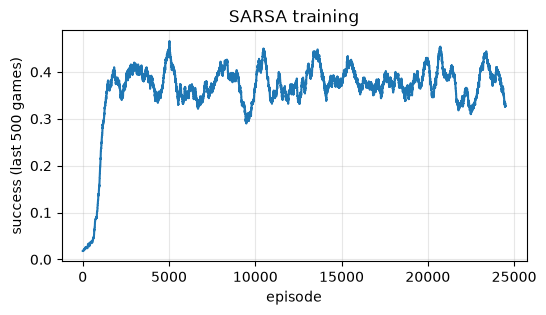

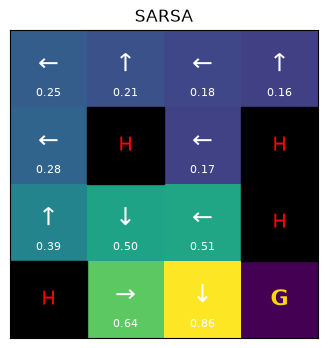

In [10]:
# learning curve: success rate over the last 500 episodes during training
plt.figure(figsize=(6, 3))
plt.plot(np.convolve(rewards_sarsa, np.ones(500) / 500, mode="valid"))
plt.title("SARSA training"); plt.xlabel("episode"); plt.ylabel("success (last 500 games)"); plt.grid(alpha=.3); plt.show()

# learned policy and values
show_policy(policy_sarsa, Q_sarsa, env, title="SARSA")

In [11]:
def test_policy(policy, env, num_episodes=1000):
    # count successes
    successes = 0

    # loop over episodes
    for _ in range(num_episodes):
        # reset env
        state, _ = env.reset()
        done = False

        # follow the policy until terminated or truncated
        while not done:
            state, reward, terminated, truncated, _ = env.step(int(policy[state]))
            done = terminated or truncated

        # success if final reward == 1
        successes += (reward == 1)

    # print and return success rate
    rate = successes / num_episodes
    print(f"Success rate: {rate:.1%}")
    return rate

In [12]:
# success rate of the greedy SARSA policy (optimal is about 74%)
sarsa_rate = test_policy(policy_sarsa, env)

Success rate: 72.4%


**What I see:**
- **The training curve** starts at almost 0 (Q is all zeros, the agent is basically wandering), and climbs once the goal's reward starts spreading back through the Q table. It levels off well below the final test score (around 40% vs ~72%), because during training ε-exploration is still on, and random moves on a slippery lake often end in a hole.
- **The greedy test:** after training, I play 1,000 games following the learned policy exactly (no random moves) and count how often it reaches the goal. It gets close to the ~74% that the optimal policy from value iteration gets, and SARSA got there without ever looking at the MDP (only `reset` and `step`) and without waiting for the end of any game to update.
- **The policy looks weird but is smart:** e.g. at state 1, right above a hole, it says **Up**, i.e. walk into the wall. On the slippery lake I only move where I pick 1/3 of the time, otherwise I slide sideways. Down, Left and Right can all end up moving me down into the hole; Up is the only action whose outcomes (stay put, slide left, slide right) never go down. Slow but safe. Value iteration found the same moves using the full model, and SARSA rediscovered them just by playing.

## 13. SARSA on CliffWalking: playing it safe

CliffWalking is a 4×12 grid: start bottom-left, goal bottom-right, and the bottom row in between is a cliff. Every step costs −1, stepping into the cliff costs −100 and sends me back to the start. The shortest path runs right along the cliff edge.

Classic setup: $\alpha = 0.5$, $\varepsilon = 0.1$ (kept on throughout), $\gamma = 1$, 500 episodes.

This is where on-policy really shows. Because SARSA's Q values include its own random moves, walking right next to the cliff looks **risky**: every so often an exploratory step would send it over the edge for −100. So SARSA should prefer a path that keeps some distance from the edge.

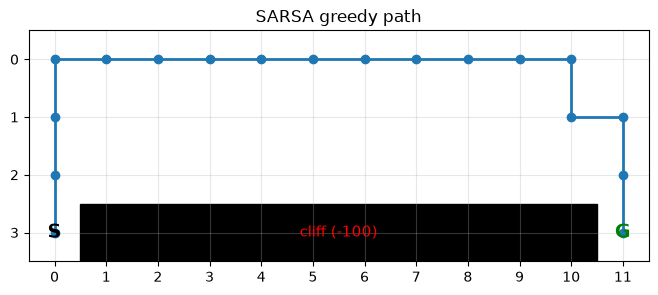

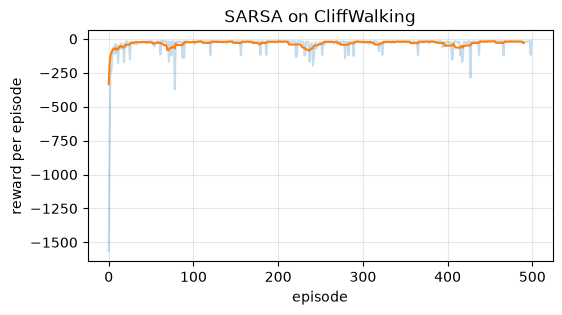

In [13]:
# CliffWalking env (use "CliffWalking-v0" on older gymnasium versions)
cliff = gym.make("CliffWalking-v1")
cliff.reset(seed=0); cliff.action_space.seed(0)

# train SARSA on the cliff
Q_cliff, rewards_cliff = sarsa(cliff, num_episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1)

# greedy path learned by SARSA
show_cliff_path(Q_cliff, "SARSA greedy path")
plot_curve(rewards_cliff, title="SARSA on CliffWalking", xlabel="episode", ylabel="reward per episode", smooth=10)

**What I see:** SARSA learns the **safe path**: it goes up away from the cliff, walks along the top, and comes back down at the end. It's longer than the path along the edge, but SARSA knows it's playing ε-greedy, and next to the cliff, one random step down costs −100. Its Q values already include that risk.

The training reward settles around −20 per episode: a slightly longer path, with only the occasional spike down to −100 or worse when exploration happens to send it towards the edge.

That's the core of on-policy learning: SARSA learns the best way to act **given that it keeps exploring**. In the Q-learning notebook, the same experiment gives a very different answer.

## 14. Summary: Monte Carlo vs TD

|  | Monte Carlo | TD (SARSA) |
| --- | --- | --- |
| Target | $G_t$, the actual return till the end of the game | $r + \gamma\, Q(s', a')$, one real reward + my current estimate |
| When it updates | After the whole game | After every step |
| Needs complete episodes? | Yes | No, works for never-ending tasks too |
| Bias | None ($G_t$ is the real return) | Some, from bootstrapping off imperfect estimates (shrinks as Q improves) |
| Variance | High (every random step till the end adds up) | Low (only one step of randomness) |
| Policy improvement | Explicit, after evaluating with many games | Implicit, every step (ε-greedy from the current Q) |

**Key takeaways:**
- TD learning replaces the full return $G_t$ with $r + \gamma \times$ (my current estimate of the future), so Q can be updated after every single step instead of after every game.
- That's bootstrapping: TD samples experience like Monte Carlo, but leans on its own estimates like DP. The trade-off is a bit of bias for much lower variance.
- SARSA is on-policy: it bootstraps from the action it's **actually** going to take next, so it learns the value of the ε-greedy policy it's playing, exploration included. That's why it plays it safe on CliffWalking.
- There's no separate policy improvement step: the policy is always ε-greedy with respect to the current Q, so every update to Q is also an improvement to the policy (generalised policy iteration).
- Practical details matter: break ties randomly with a zero-initialised Q, and only stop bootstrapping on **termination**, not truncation.

**What's next:** Q-learning. Swap $Q(s', a')$ for $\max_{a'} Q(s', a')$ and learning becomes **off-policy**: the agent can explore randomly but still learn the values of the greedy policy. It's basically value iteration done with samples, and on CliffWalking it takes the risky path right along the edge.